#### Задание
Чем активнее пользователи – тем выше нагрузка на сервера. И в последнее время всё чаще приходят жалобы, что приложение подвисает. Ваша задача – спрогнозировать, как изменится активность пользователей в течение ближайшего месяца.  

1. Выберите ключевую метрику, которую будете прогнозировать, и обоснуйте свой выбор. Укажите, с каким временным шагом будет строиться прогноз. Также определите, есть ли дополнительные факторы, которые стоит использовать в качестве регрессоров.
2. Постройте прогнозную модель и проведите ее валидацию. Оцените, достаточно ли имеющихся данных для полноценного бэктестинга на заданном горизонте. Если данных недостаточно, определите, для какого горизонта прогнозирования их объема будет достаточно.
3. Выберите наиболее подходящую модель, объясните, почему остановились именно на ней, и интерпретируйте полученные результаты. Отдельно отметьте ограничения, которые важно учитывать при использовании прогноза.

,date,total_events,views,likes,DAU
0,2025-12-06,9163,7603,1560,878
1,2025-12-07,75586,62770,12816,2238
2,2025-12-08,126484,105526,20958,3105
3,2025-12-09,142796,118996,23800,3721
4,2025-12-10,208958,174454,34504,4617


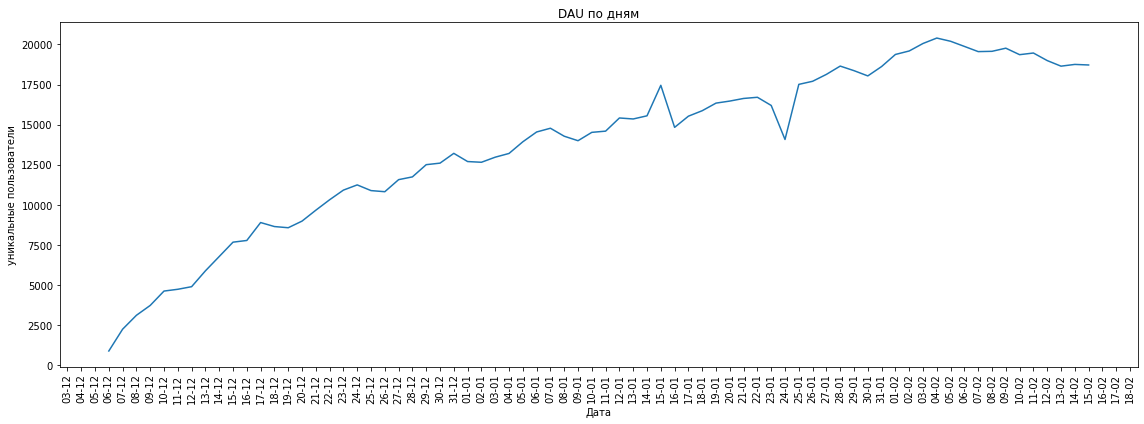

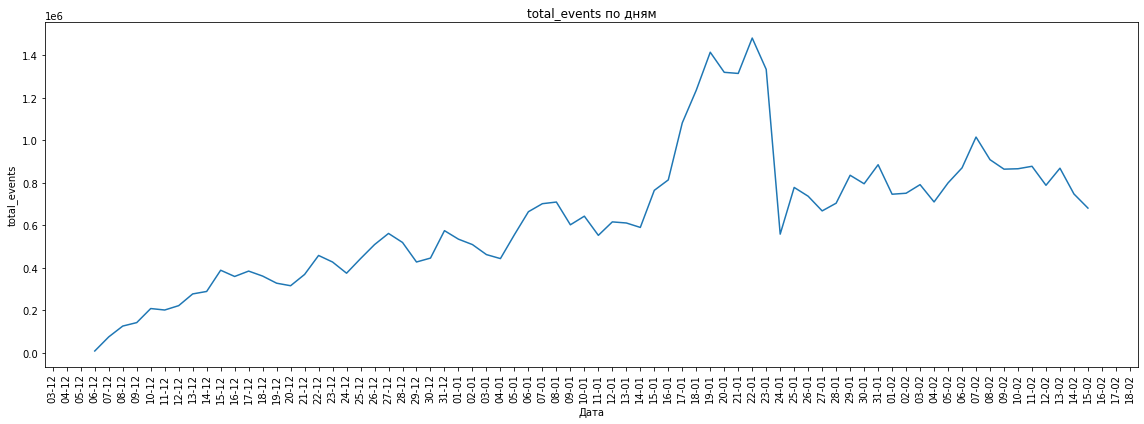

In [39]:
import swifter
import hashlib
import scipy.stats as stats
from IPython.display import display
import matplotlib.dates as mdates

import orbit #общий пакет
from orbit.models import DLT 
from orbit.models import LGT
from orbit.models import KTR
from orbit.diagnostics.plot import plot_predicted_data, plot_predicted_components #для рисования предсказаний
from orbit.diagnostics.backtest import BackTester
from orbit.utils.params_tuning import grid_search_orbit
from orbit.diagnostics.metrics import wmape

import pandas as pd
import pandahouse
import numpy as np
import os

import seaborn as sns
import matplotlib.pyplot as plt
import arviz as az #это полезно для визуализации MCMC

# Подавляем предупреждения Matplotlib о шрифтах ("Arial not found")
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

connection = {
    'host': 'http://*************',
    'password': '**********',
    'user': '********',
    'database': '**********'
}

q = """
SELECT
    toDate(time) AS date,
    countIf(action='view') + countIf(action='like') AS total_events,
    countIf(action='view') AS views,
    countIf(action='like') AS likes,
    count(DISTINCT user_id) AS DAU

FROM ************
WHERE time < toStartOfDay(now())
GROUP BY date
ORDER BY date
"""
df= pandahouse.read_clickhouse(q,connection=connection)
display(df.head())


df['date'] = pd.to_datetime(df['date'])

plt.figure(figsize=(16, 6))
plt.plot(df['date'], df['DAU'])
plt.title('DAU по дням')
plt.xlabel('Дата')
plt.ylabel('уникальные пользователи')
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


plt.figure(figsize=(16, 6))
plt.plot(df['date'], df['total_events'])
plt.title('total_events по дням')
plt.xlabel('Дата')
plt.ylabel('total_events')
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


По данным построены дневные ряды total_events = views + likes и DAU. На графиках видно, что ряд total_events отражает общий объём пользовательских действий и, как следствие, ближе всего соответствует нагрузке на инфраструктуру. DAU используется как вспомогательная метрика для проверки, связано ли изменение нагрузки с ростом аудитории или с изменением интенсивности действий на пользователя.  

Данные агрегированы по дням: такое разрешение сглаживает внутридневной шум и соответствует целевому горизонту планирования на ~1 месяц.  

На временных рядах присутствуют аномальные периоды, связанные с внешними событиями: флэшмоб (16.01.2026–22.01.2026) и единичный технический сбой (24.01.2026). Чтобы не “обучать” модель на разовых всплесках как на нормальной динамике и получить более корректный базовый прогноз, добавим в модель бинарные регрессоры для этих событий.  

Для прогноза и сравнения качества рассмотрим три семейства моделей Orbit (DLT, LGT, KTR) и оценим их точность на бэктесте на горизонтах 14 и 30 дней.

2026-02-16 09:17:21 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.
INFO:orbit:Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

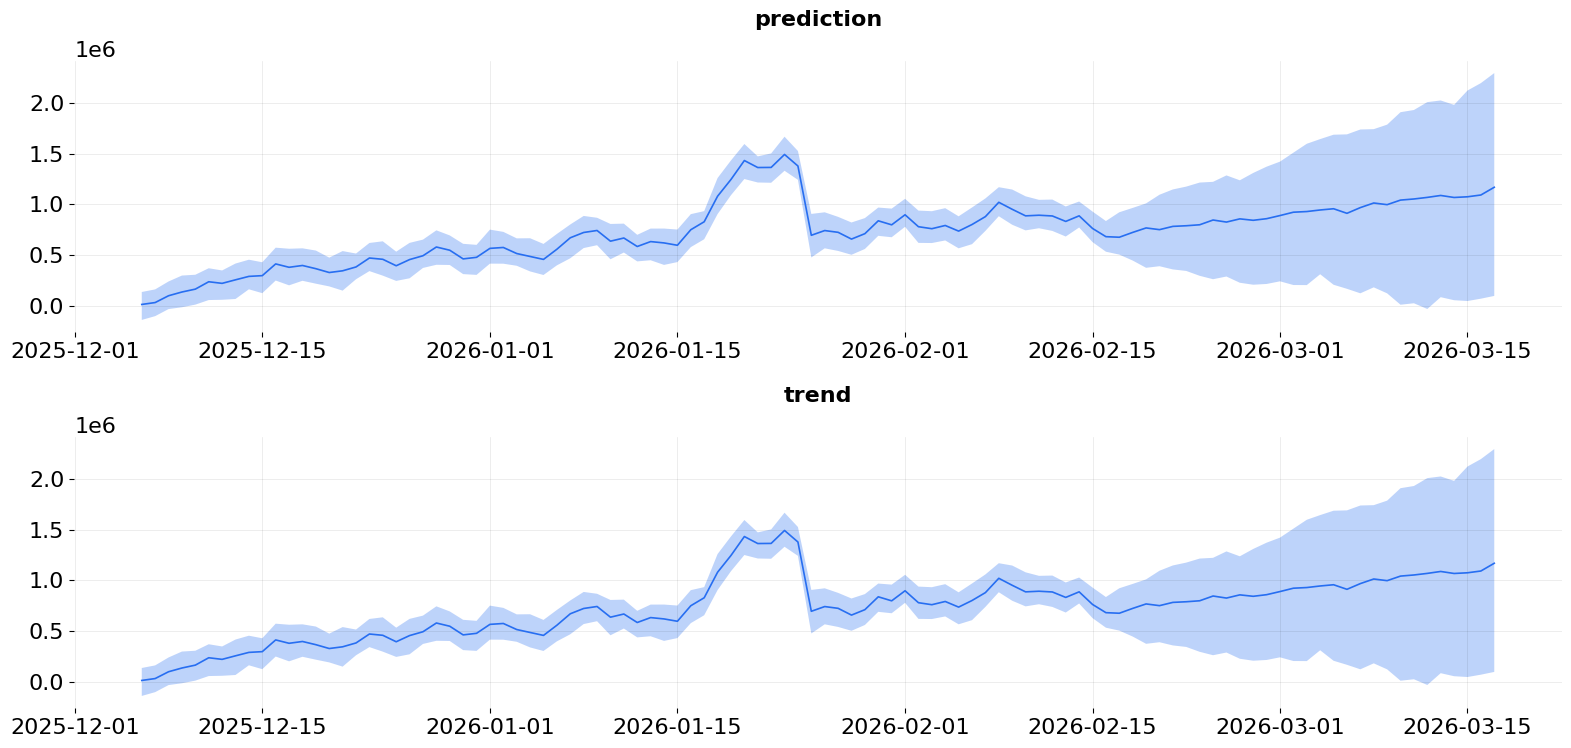

In [40]:
# Модель DLT
# Оставляем в датафрейме только то, что нужно модели:
# - date: временная ось
# - total_events: целевая метрика (views + likes)
df = df[['date', 'total_events']].copy()
df = df.sort_values('date').copy()
df['date'] = pd.to_datetime(df['date'])

# регрессоры
df['flashmob'] = ((df['date'] >= '2026-01-16') & (df['date'] <= '2026-01-22')).astype(int)
df['incident_20260124'] = (df['date'] == '2026-01-24').astype(int)

# Обучаем модель DLT 
model_DLT = DLT(
    response_col='total_events', #  прогнозируемое событие
    date_col='date', # временная колонка
    regressor_col=['flashmob', 'incident_20260124'], # регрессоры
    estimator='stan-mcmc', # для повышения точности прогнозов используем stan-mcmc
)
# Обучаем модель на исторических данных
model_DLT.fit(df)

# прогноз на будущее
horizon = 30
future_dates = pd.date_range(df['date'].max() + pd.Timedelta(days=1), periods=horizon, freq='D')
# Собираем будущий датафрейм
future_df = pd.DataFrame({'date': future_dates})
# Для будущих дат флэшмоб и сбой считаем равными 0 (их уже нет/не ожидается)
future_df['flashmob'] = 0
future_df['incident_20260124'] = 0

# Предсказания + декомпозиция на компоненты
pred_hist = model_DLT.predict(df=df, decompose=True)
pred_future = model_DLT.predict(df=future_df, decompose=True)
pred_all = pd.concat([pred_hist, pred_future], ignore_index=True)

# Визуализация компонентов модели
_ = plot_predicted_components(
    pred_all,
    date_col="date",
    plot_components=["prediction", "trend"]
)

In [41]:
# Попробуем как дополнительный оптимальный параметр рассмотреть недельную сезонность
dlt_tune = DLT(
    response_col="total_events",
    date_col="date",
    regressor_col=["flashmob", "incident_20260124"],
    estimator="stan-mcmc"
)
best_params, tuned_df = grid_search_orbit(
    param_grid={"seasonality": [0, 7]},
    model=dlt_tune,
    df=df,
    eval_method="backtest",
    min_train_len=42,
    incremental_len=7,
    forecast_len=30,
    metrics=wmape,
    criteria="min",
    verbose=True
)

print("Best params:", best_params)
display(tuned_df.sort_values("metrics"))

  0%|          | 0/2 [00:00<?, ?it/s]

2026-02-16 09:17:58 - orbit - INFO - tuning hyper-params {'seasonality': 0}
INFO:orbit:tuning hyper-params {'seasonality': 0}
2026-02-16 09:17:58 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.
INFO:orbit:Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

...

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

2026-02-16 09:18:03 - orbit - INFO - tuning metric:0.48332
INFO:orbit:tuning metric:0.48332



Best params: [{'seasonality': 7}]


,seasonality,metrics
1,7,0.483321
0,0,0.497675


2026-02-16 09:18:07 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.
INFO:orbit:Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

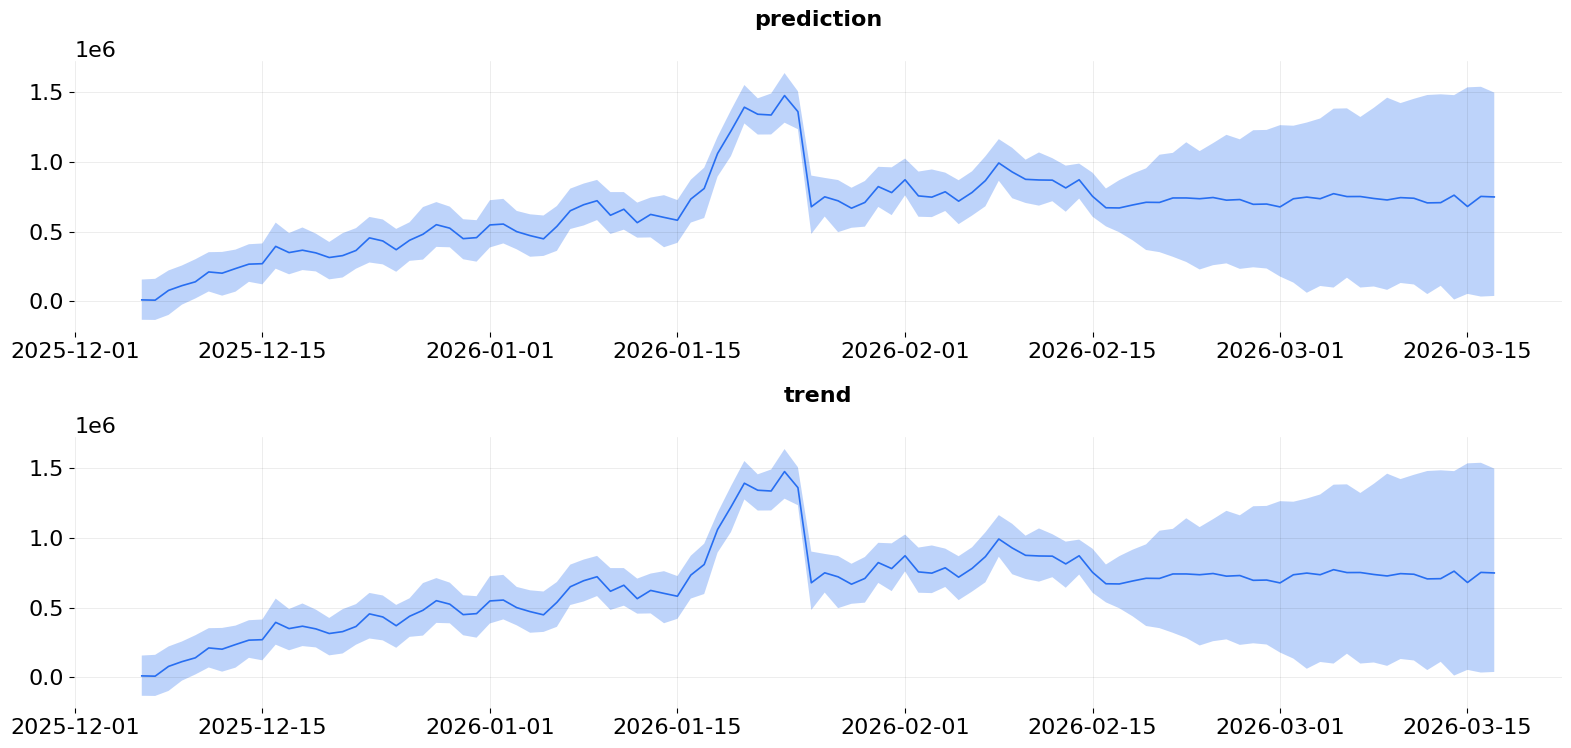

In [42]:
# Модель LGT
model_LGT = LGT(
    response_col='total_events',
    date_col='date',
    regressor_col=['flashmob', 'incident_20260124'],
    estimator='stan-mcmc',

)

model_LGT.fit(df)

# прогноз на будущее
horizon = 30
future_dates = pd.date_range(df['date'].max() + pd.Timedelta(days=1), periods=horizon, freq='D')
future_df = pd.DataFrame({'date': future_dates})
future_df['flashmob'] = 0
future_df['incident_20260124'] = 0

pred_hist = model_LGT.predict(df=df, decompose=True)
pred_future = model_LGT.predict(df=future_df, decompose=True)
pred_all = pd.concat([pred_hist, pred_future], ignore_index=True)

_ = plot_predicted_components(
    pred_all,
    date_col="date",
    plot_components=["prediction", "trend"]
)


In [43]:
# Попробуем как дополнительный оптимальный параметр рассмотреть недельную сезонность
lgt_tune = LGT(
    response_col="total_events",
    date_col="date",
    regressor_col=["flashmob", "incident_20260124"],
    estimator="stan-mcmc"
)

best_params, tuned_df = grid_search_orbit(
    param_grid={"seasonality": [0, 7]},
    model=lgt_tune,
    df=df,
    eval_method="backtest",
    min_train_len=42,
    incremental_len=7,
    forecast_len=30,
    metrics=wmape,
    criteria="min",
    verbose=True
)
print("Best params:", best_params)
display(tuned_df.sort_values("metrics"))

  0%|          | 0/2 [00:00<?, ?it/s]

2026-02-16 09:18:14 - orbit - INFO - tuning hyper-params {'seasonality': 0}
INFO:orbit:tuning hyper-params {'seasonality': 0}
2026-02-16 09:18:14 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.
INFO:orbit:Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

...

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

2026-02-16 09:18:15 - orbit - INFO - tuning metric:0.24849
INFO:orbit:tuning metric:0.24849



Best params: [{'seasonality': 0}]


,seasonality,metrics
0,0,0.19815
1,7,0.24849


2026-02-16 09:18:56 - orbit - INFO - Optimizing (PyStan) with algorithm: LBFGS.
INFO:orbit:Optimizing (PyStan) with algorithm: LBFGS.
2026-02-16 09:18:56 - orbit - INFO - Using SVI (Pyro) with steps: 301, samples: 100, learning rate: 0.1, learning_rate_total_decay: 1.0 and particles: 100.
INFO:orbit:Using SVI (Pyro) with steps: 301, samples: 100, learning rate: 0.1, learning_rate_total_decay: 1.0 and particles: 100.
2026-02-16 09:18:56 - orbit - INFO - step    0 loss = 1034.4, scale = 0.089339
INFO:orbit:step    0 loss = 1034.4, scale = 0.089339
2026-02-16 09:18:58 - orbit - INFO - step  100 loss = 1017.2, scale = 0.25285
INFO:orbit:step  100 loss = 1017.2, scale = 0.25285
2026-02-16 09:19:00 - orbit - INFO - step  200 loss = 1017.1, scale = 0.31837
INFO:orbit:step  200 loss = 1017.1, scale = 0.31837
2026-02-16 09:19:02 - orbit - INFO - step  300 loss = 1016, scale = 0.35296
INFO:orbit:step  300 loss = 1016, scale = 0.35296


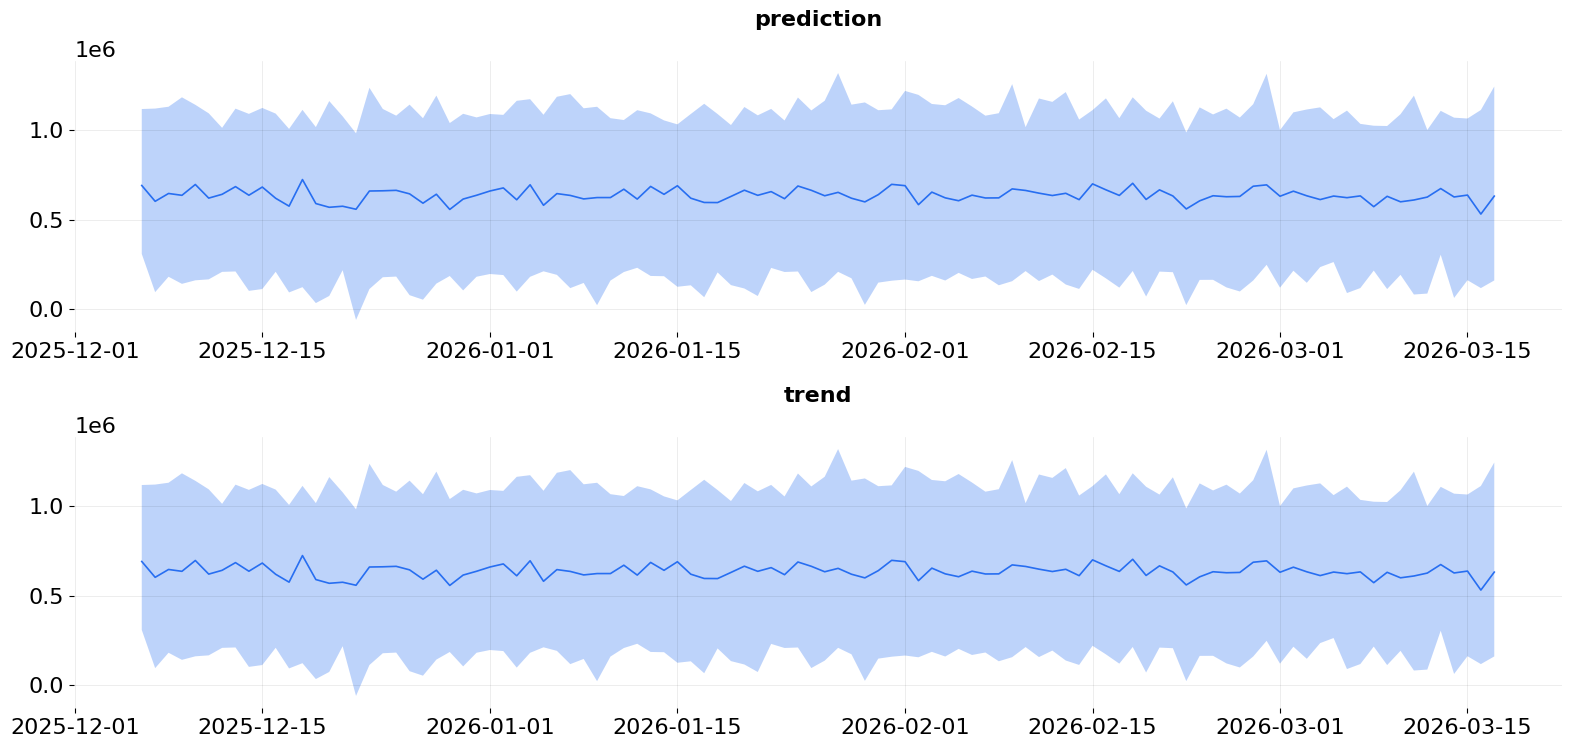

In [45]:
# Модель KTR
df['flashmob'] = ((df['date'] >= '2026-01-16') & (df['date'] <= '2026-01-22')).astype(int)
df['incident_20260124'] = (df['date'] == '2026-01-24').astype(int)

# FIX: типы для pyro
df['total_events'] = df['total_events'].astype('float64')
df['flashmob'] = df['flashmob'].astype('int64')
df['incident_20260124'] = df['incident_20260124'].astype('int64')

model_KTR = KTR(
    response_col='total_events',
    date_col='date',
    regressor_col=['flashmob', 'incident_20260124'],
    estimator='pyro-svi'

)
model_KTR.fit(df)

horizon = 30
future_dates = pd.date_range(df['date'].max() + pd.Timedelta(days=1), periods=horizon, freq='D')
future_df = pd.DataFrame({'date': future_dates})
future_df['flashmob'] = 0
future_df['incident_20260124'] = 0

# FIX: типы для pyro
future_df['flashmob'] = future_df['flashmob'].astype('int64')
future_df['incident_20260124'] = future_df['incident_20260124'].astype('int64')

pred_hist = model_KTR.predict(df=df, decompose=True)
pred_future = model_KTR.predict(df=future_df, decompose=True)
pred_all = pd.concat([pred_hist, pred_future], ignore_index=True)

_ = plot_predicted_components(
    pred_all,
    date_col="date",
    plot_components=["prediction", "trend", "seasonality"]
)

##### Промежуточные выводы  
Были построены прогнозы тремя моделями Orbit (DLT, LGT, KTR) и визуально сравнили их поведение на обучающем периоде и на горизонте прогноза.  

##### DLT  
DLT воспроизводит общий рост метрики и после окончания наблюдений продолжает восходящую динамику. При этом на горизонте прогноза доверительный интервал заметно расширяется, что указывает на высокую неопределённость в оценке тренда при относительно короткой истории и наличии сильных разовых событий. Дополнительно проверили влияние недельной сезонности через grid-search: для DLT вариант seasonality=7 даёт лишь незначительное улучшение WMAPE по сравнению с seasonality=0, то есть вклад сезонности для этой модели невелик и не является определяющим.

##### LGT  
LGT даёт более “сдержанный” прогноз: после середины февраля медианный уровень выглядит стабильнее и ближе к текущему уровню ряда, при этом неопределённость также растёт с горизонтом. Такая форма прогноза может быть более устойчива, если наблюдаемый рост в конце периода замедляется. По результатам grid-search для LGT оптимальным является seasonality=0: добавление недельной сезонности ухудшает качество (ошибка заметно выше), поэтому сезонность в дальнейших экспериментах учитывать не будем.

##### KTR  
KTR формирует практически плоский прогноз, слабо реагируя на наблюдавшийся ранее рост. Это может означать, что модель хуже захватывает тренд в данных и больше “уходит” в уровневую аппроксимацию, что потенциально снижает качество на длинном горизонте.  


После визуального сравнения прогнозов DLT, LGT и KTR видно, что модели по-разному интерпретируют базовую динамику ряда и по-разному оценивают неопределённость на горизонте прогноза. Однако по графикам нельзя объективно выбрать лучшую модель: визуальные различия не дают количественной оценки точности и могут быть чувствительны к выбору параметров (окна обучения, горизонта). 
Поэтому далее переходим к бэктесту: будем последовательно обучать модели на исторических окнах и проверять качество на отложенных периодах. Для сравнения используем метрики ошибки (WMAPE, MAE, MAPE) на горизонтах 14 и 30 дней, а также посмотрим влияние типа окна (expanding/rolling) и минимальной длины обучающей выборки. Результаты сведём в таблицу. 
При горизонте 30 дней бэктест возможен, но из-за короткой истории число валидных окон ограничено, поэтому оценка качества может быть менее стабильной — этот фактор учитываем при интерпретации результатов.

In [46]:
def bt_grid_scores_wide(model, df,
                        min_train_lens=(28, 35, 42),
                        forecast_lens=(14, 30),
                        window_types=("expanding", "rolling"),
                        incremental_len=7,
                        metrics=("wmape", "mae", "rmse", "mape"),
                        round_digits=4):
    rows = []
    for wt in window_types:
        for mtl in min_train_lens:
            for fl in forecast_lens:
                row = {"window_type": wt, "min_train_len": mtl, "forecast_len": fl}
                try:
                    bt = BackTester(
                        model=model,
                        df=df,
                        min_train_len=mtl,
                        incremental_len=incremental_len,
                        forecast_len=fl,
                        window_type=wt
                    )
                    bt.fit_predict()
                    sc = bt.score()
                    sc = sc[sc["is_training_metric"] == False]  # только test

                    for met in metrics:
                        s = sc.loc[sc["metric_name"] == met, "metric_values"]
                        row[met] = float(s.iloc[0]) if len(s) else None
                except Exception:
                    for met in metrics:
                        row[met] = None

                rows.append(row)

    res = pd.DataFrame(rows)

    wide = (
        res.pivot_table(
            index=["window_type", "min_train_len"],
            columns="forecast_len",
            values=list(metrics),
            aggfunc="mean"
        )
        .sort_index(axis=1, level=1)  # чтобы 14,30 шли по порядку
    )

    
    wide.columns = [f"{met}_{fl}" for met, fl in wide.columns]
    return wide.round(round_digits)

In [47]:
scores_wide = bt_grid_scores_wide(model_DLT, df, metrics=("wmape","mae","rmse","mape"))
scores_wide

2026-02-16 09:19:29 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.
INFO:orbit:Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

mae_14  mape_14  wmape_14       mae_30  \
window_type min_train_len                                                
expanding   28             337811.3423   0.4083    0.3996  309549.7550   
            35             385854.8922   0.4471    0.4284  341064.9137   
            42             406729.7829   0.5090    0.4660  465786.8044   
rolling     28             337683.1212   0.4013    0.3994  301560.8719   
            35             399855.8579   0.4643    0.4439  406762.8477   
            42             438630.0898   0.5472    0.5026  398923.4251   

                           mape_30  wmape_30  
window_type min_train_len                     
expanding   28              0.3524    0.3552  
            35              0.3903    0.3804  
            42              0.5496    0.5091  
rolling     28              0.3401    0.3460  
            35              0.4706    0.4537  
            42              0.4659    0.4360

In [48]:
scores_wide = bt_grid_scores_wide(model_LGT, df, metrics=("wmape","mae","rmse","mape"))
scores_wide

2026-02-16 09:22:24 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.
INFO:orbit:Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

mae_14  mape_14  wmape_14       mae_30  \
window_type min_train_len                                                
expanding   28             299189.4841   0.3386    0.3539  235415.1379   
            35             336742.7924   0.3688    0.3739  263673.4361   
            42             326919.8330   0.3924    0.3746  180239.2224   
rolling     28             297634.4737   0.3346    0.3521  250226.5704   
            35             346560.4622   0.3788    0.3848  241054.4608   
            42             343148.9553   0.4131    0.3932  184511.1621   

                           mape_30  wmape_30  
window_type min_train_len                     
expanding   28              0.2284    0.2701  
            35              0.2661    0.2941  
            42              0.1761    0.1970  
rolling     28              0.2462    0.2871  
            35              0.2335    0.2689  
            42              0.1881    0.2017

In [49]:
scores_wide = bt_grid_scores_wide(model_KTR, df, metrics=("wmape","mae","rmse","mape"))
scores_wide

2026-02-16 09:23:51 - orbit - INFO - Optimizing (PyStan) with algorithm: LBFGS.
INFO:orbit:Optimizing (PyStan) with algorithm: LBFGS.
2026-02-16 09:23:51 - orbit - INFO - Using SVI (Pyro) with steps: 301, samples: 100, learning rate: 0.1, learning_rate_total_decay: 1.0 and particles: 100.
INFO:orbit:Using SVI (Pyro) with steps: 301, samples: 100, learning rate: 0.1, learning_rate_total_decay: 1.0 and particles: 100.
2026-02-16 09:23:51 - orbit - INFO - step    0 loss = 384.57, scale = 0.095453
INFO:orbit:step    0 loss = 384.57, scale = 0.095453
2026-02-16 09:23:53 - orbit - INFO - step  100 loss = 375.28, scale = 0.33654
INFO:orbit:step  100 loss = 375.28, scale = 0.33654
2026-02-16 09:23:55 - orbit - INFO - step  200 loss = 374.99, scale = 0.39176
INFO:orbit:step  200 loss = 374.99, scale = 0.39176
2026-02-16 09:23:57 - orbit - INFO - step  300 loss = 374.93, scale = 0.43338
INFO:orbit:step  300 loss = 374.93, scale = 0.43338
2026-02-16 09:23:57 - orbit - INFO - Optimizing (PyStan) w

mae_14  mape_14  wmape_14       mae_30  \
window_type min_train_len                                                
expanding   28             377357.5936   0.4057    0.4464  475138.8310   
            35             403057.2464   0.4011    0.4475  477477.2465   
            42             339804.1183   0.3525    0.3893  472828.1791   
rolling     28             285915.8680   0.2996    0.3382  419111.5376   
            35             326490.6660   0.3090    0.3625  448532.6348   
            42             281281.2990   0.2819    0.3223  472828.1791   

                           mape_30  wmape_30  
window_type min_train_len                     
expanding   28              0.5082    0.5452  
            35              0.4997    0.5326  
            42              0.4872    0.5168  
rolling     28              0.4414    0.4809  
            35              0.4663    0.5003  
            42              0.4872    0.5168

##### Промежуточные выводы  

##### DLT

На горизонте 30 дней даёт среднее качество: лучший wmape_30 ≈ 0.34 (rolling, train=28), хуже LGT.  
Чувствительна к длине обучения: при min_train_len=42 метрики заметно ухудшаются,  возможная нестационарность.  
Можно рассматривать как запасной вариант, но не основной.  

##### LGT

Лучшая по точности на ключевом горизонте: wmape_30 ≈ 0.19, mae_30 ≈ 180–184.  
Стабильна к выбору окна (rolling/expanding) при min_train_len=42.  
Основной кандидат для финального прогноза.  

##### KTR

Худшая по всем метрикам: wmape_30 ≈ 0.48–0.54, mae_30 ≈ 419–475k.  
Вероятно, недостаточно хорошо описывает тренд (склонна к “плоскому” прогнозу).  
Для задачи прогноза нагрузки не подходит.  

История наблюдений составляет порядка 2 месяцев, поэтому при бэктесте с шагом 7 дней и минимальным окном обучения 28–42 дня мы получаем достаточно тестовых окон для устойчивой оценки качества на горизонтах 14 и 30 дней. Для горизонта 30 дней количество валидных окон заметно сокращается, и оценка становится менее стабильной. По результатам бэктеста лучшей оказалась LGT, поэтому для финального прогноза используем её. Так как параметры модели оцениваются через MCMC, проверим сходимость цепей и качество смешивания.

2026-02-16 09:30:02 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 2000 and samples(per chain): 2000.
INFO:orbit:Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 2000 and samples(per chain): 2000.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

,mean,sd,r_hat,ess_bulk,ess_tail
obs_sigma,81298.459,9003.676,1.0,7848.0,5466.0


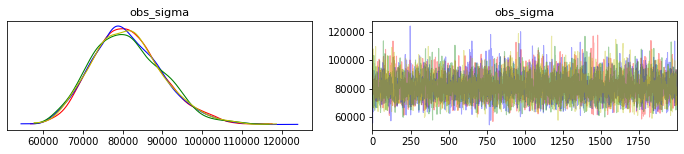

In [50]:
model_LGT = LGT(
    response_col="total_events",
    date_col="date",
    regressor_col=["flashmob", "incident_20260124"],
    estimator="stan-mcmc",
    num_warmup=8000,   # время "разогрева"
    num_sample=8000    # время сэмплирования
)

model_LGT.fit(df)
params = model_LGT.get_posterior_samples(permute=False, relabel=True)
az.plot_trace(params, chain_prop={"color": ['r', 'b', 'g', 'y']}, var_names="obs_sigma")
az.summary(params, var_names=["obs_sigma"])[["mean","sd","r_hat","ess_bulk","ess_tail"]]

Проверка MCMC-диагностики для выбранной модели LGT показывает, что оценка параметров выполнена корректно: по параметру шума obs_sigma цепи хорошо смешиваются, а метрики сходимости подтверждают результат (r_hat = 1.0, эффективный размер выборки высокий). Среднее значение obs_sigma составляет порядка 81 тыс. (sd ≈ 9 тыс.), что отражает масштаб остаточной вариативности ряда, не объясняемой трендом и регрессорами. Следовательно, прогнозные интервалы модели LGT можно считать надёжными, и модель подходит для построения финального прогноза нагрузки на горизонте 30 дней.

##### Итоговые выводы

Итоговый выбор модели: LGT — наиболее удачная для данной задачи, так как она даёт минимальную ошибку на целевом горизонте 30 дней и при этом демонстрирует устойчивость к настройкам бэктеста. Модель интерпретирует динамику активности пользователей как сочетание базового тренда и остаточных колебаний, а разовые события (флэшмоб и технический сбой) учитываются через регрессоры и не искажают оценку “нормального” уровня нагрузки.  
При интерпретации прогноза важно учитывать, что ряд остаётся шумным (уровень остаточной вариативности порядка obs_sigma ≈ 81k), поэтому для планирования инфраструктуры следует ориентироваться не только на медианный прогноз, но и на верхние границы прогнозного интервала как на сценарий повышенной нагрузки.
Ограничения вывода: история данных короткая (около 2 месяцев), поэтому точность на горизонтах около месяца ограничена, а проверка выполнена на 30 днях как наиболее надёжном приближении. Кроме того, модель не предсказывает появление новых акций/сбоев: если в прогнозном периоде возникнут внеплановые события, фактическая нагрузка может существенно отклониться от ожидаемой базовой динамики.